# SVM Classification - Normalized + Smoothed Spectral Mode

**Testing normalized + smoothed spectral classification:**
- Applies **in-memory preprocessing** to generalize what `plot_spectrum` does
- Full spectral information with normalization and smoothing
- Compare performance against raw spectral (dev20) and intensity-only (dev21)

**Complete pipeline with proper naming:**
1. **Preprocessing** → Interpolate → Crop → Smooth → Normalize (in-memory)
2. **Training** → `training_*` ROIs train the SVM (using normalized+smoothed spectra)
3. **Classification** → SVM outputs `classified_*` predictions
4. **Filtering** → Small clusters become `filtered_*`
5. **Merge** → `filtered_* + classified_sediment` → `new_sediment`
6. **Validation** → Compare 3 classes against `validation_*` ROIs

**Key features:**
- ✅ **Wavelength interpolation**: Fix bad wavelengths [64, 107, 138]
- ✅ **Wavelength cropping**: 490-680 nm range
- ✅ **Moving average smoothing**: Window=10
- ✅ **L2 normalization**: Unit-length spectra
- ✅ Clear naming throughout the pipeline
- ✅ Morphological operations disabled

## Setup and Import

In [1]:
import importlib
import sys
import os
import numpy as np

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

print("✅ Module loaded successfully!")

✅ Module loaded successfully!


## Load Data and ROIs

In [2]:
# Load transect
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

# Select file
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5


  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [3]:
# Apply illumination correction
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
# Import ROIs
cube.import_rois("./ROIs/057_5_combined.json")
cube.list_rois()

📂 Imported 6 ROIs from ./ROIs/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'validation_dark': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'validation_bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'validation_sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [5]:
# Define ROI collections
training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
]

validation_rois = [
    "validation_dark",
    "validation_sediment",
    "validation_bombs",
]

print(f"Training ROIs: {training_rois}")
print(f"Validation ROIs: {validation_rois}")

Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']
Validation ROIs: ['validation_dark', 'validation_sediment', 'validation_bombs']


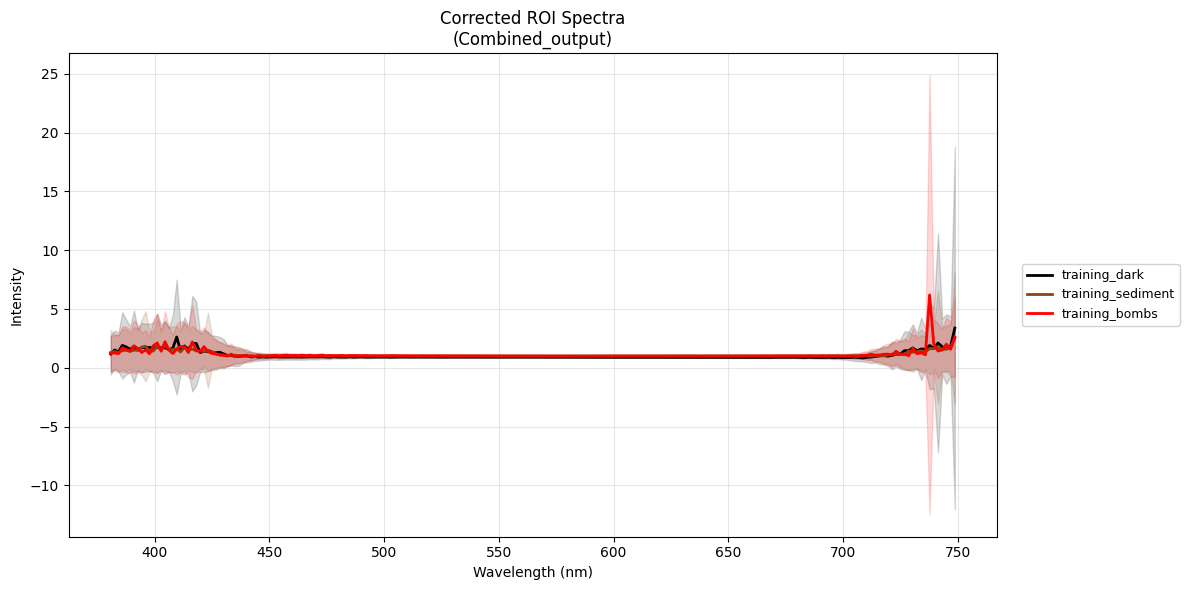

In [6]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

💡 Interactive mode: Click on the plot to display coordinates


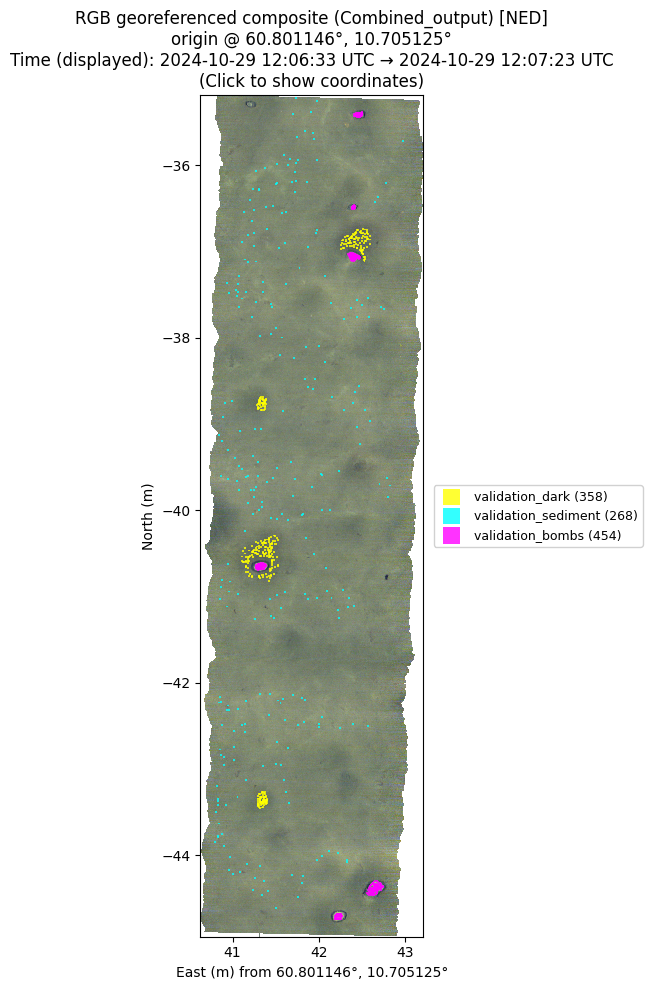

In [7]:
# Plot validation ROIs
%matplotlib inline

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection=validation_rois,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

In [8]:
# # Step 1: Interpolate bad wavelengths (fix sensor artifacts)
# cube.apply_wavelength_interpolation(interpolate_wavelengths=[64, 107, 138])
# # cube.apply_wavelength_interpolation(interpolate_wavelengths=[0, 43, 74])

# print(f"✅ Wavelength interpolation complete")
# print(f"   Shape after interpolation: {cube.data_corrected.shape}")

In [9]:
# Step 2: Crop wavelengths to 490-680 nm
cube.apply_wavelength_filter(wavelength_range=(490, 680))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube.data_corrected.shape}")
print(f"   Wavelength range: {cube.wavelengths[0]:.1f} - {cube.wavelengths[-1]:.1f} nm")

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-680 nm
✂️  Filtered wavelengths: 108
📉 Range: 490.2 - 679.4 nm



✅ Datacube shape after filtering: (2462, 968, 108)
   Memory: 0.96 GB
✅ Wavelength cropping complete
   Cropped shape: (2462, 968, 108)
   Wavelength range: 490.2 - 679.4 nm


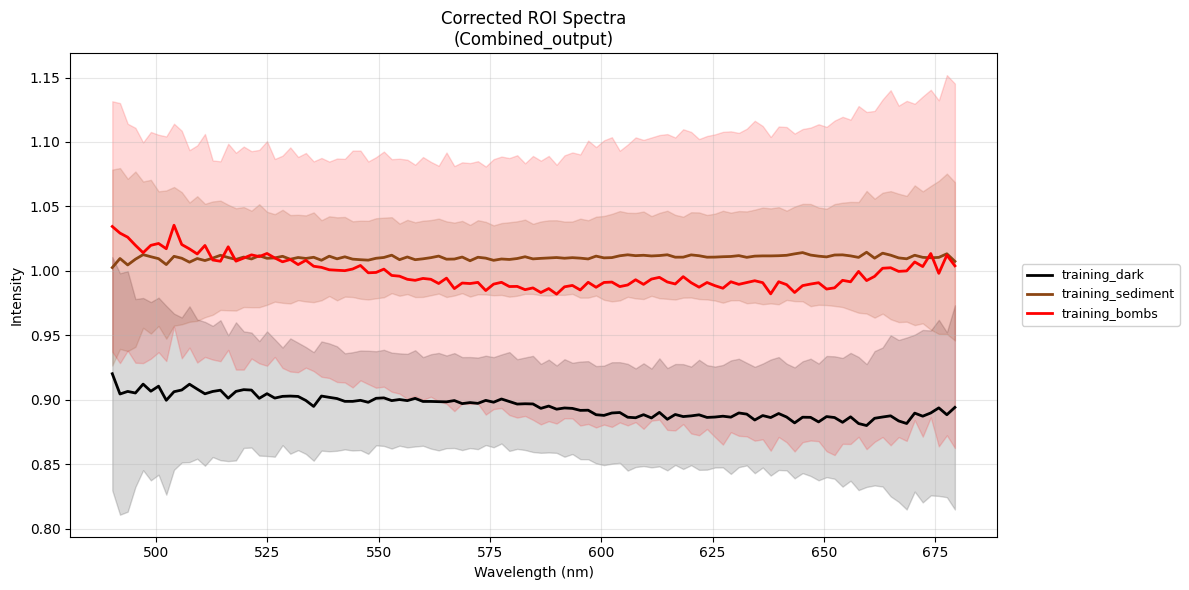

In [10]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

In [11]:
# Step 3: Smooth with moving average (window=10)
cube.apply_spectral_smoothing(wavelength_smoothing=10, method="moving_average")

print(f"✅ Spectral smoothing complete")
print(f"   Shape after smoothing: {cube.data_corrected.shape}")

🌊 SPECTRAL SMOOTHING: MOVING_AVERAGE
📊 Datacube shape: (2462, 968, 108)
🪟 Window size: 10


Smoothing spectra (moving average): 100%|██████████| 2462/2462 [04:06<00:00,  9.97it/s]




✅ Smoothing complete!
   Method: moving_average
   Window: 10
✅ Spectral smoothing complete
   Shape after smoothing: (2462, 968, 108)


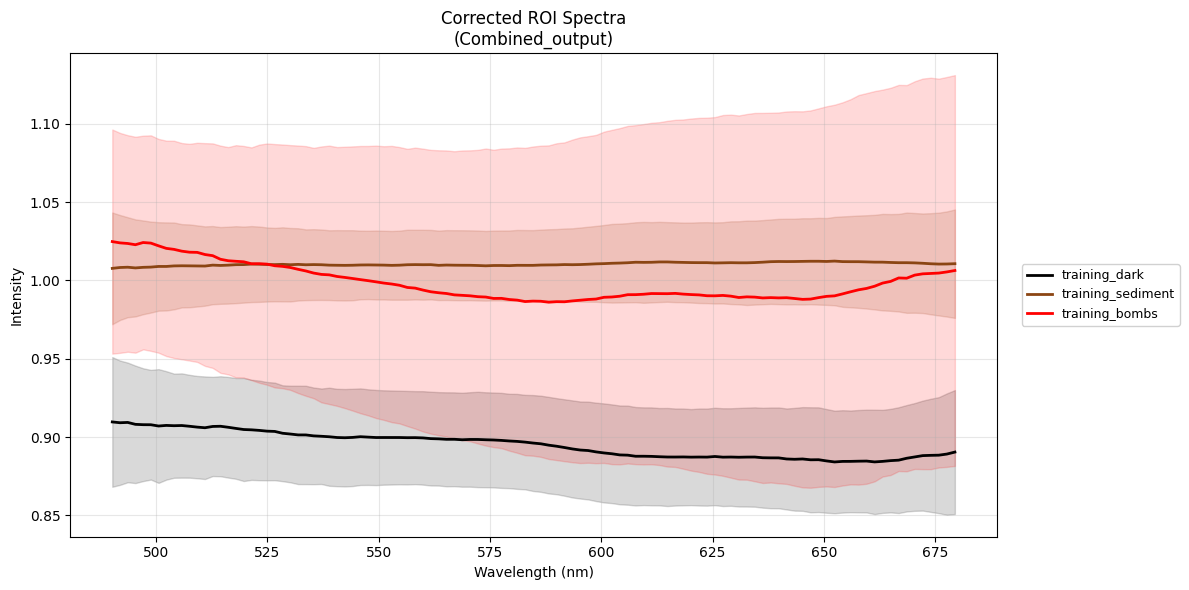

In [12]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

In [13]:
# Step 4: Normalize with L2 (unit-length spectra)
cube.apply_spectral_normalization(method="l2")

print(f"✅ L2 normalization complete")
print(
    f"   Value range: [{cube.data_corrected.min():.4f}, {cube.data_corrected.max():.4f}]"
)

📐 SPECTRAL NORMALIZATION: L2
📊 Datacube shape: (2462, 968, 108)
🌊 Wavelengths: 108 (490.2 - 679.4 nm)

✅ Normalization complete!
   Method: l2
   Value range: [0.0505, 0.1333]

✅ Normalization complete!
   Method: l2
   Value range: [0.0505, 0.1333]
✅ L2 normalization complete
   Value range: [0.0505, 0.1333]
✅ L2 normalization complete
   Value range: [0.0505, 0.1333]


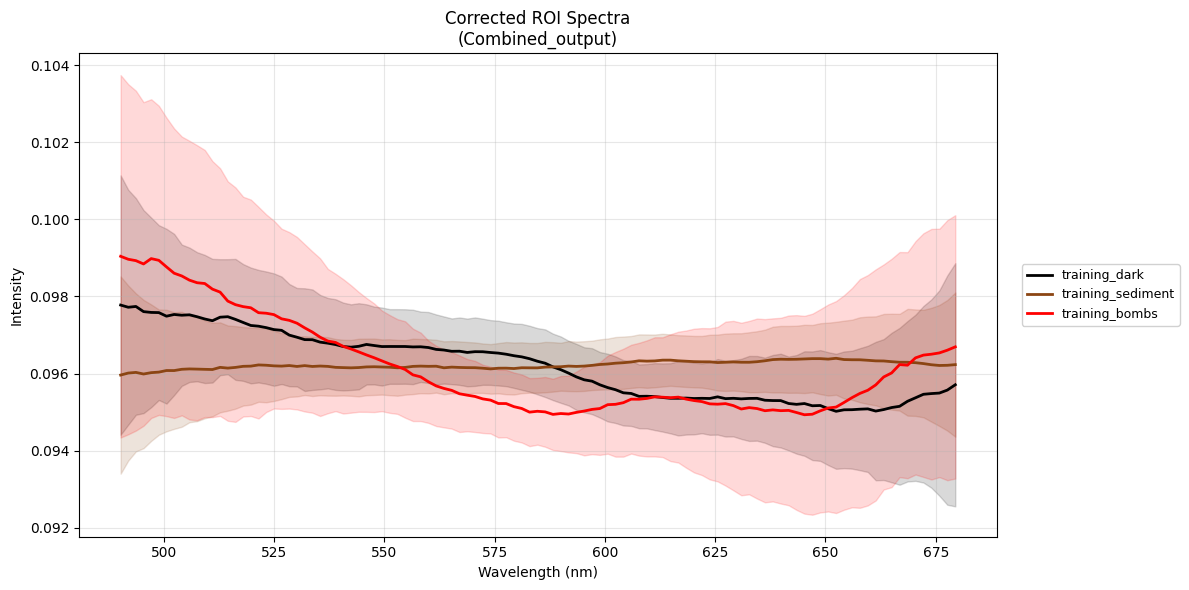

In [14]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

💡 Interactive mode: Click on the plot to display coordinates


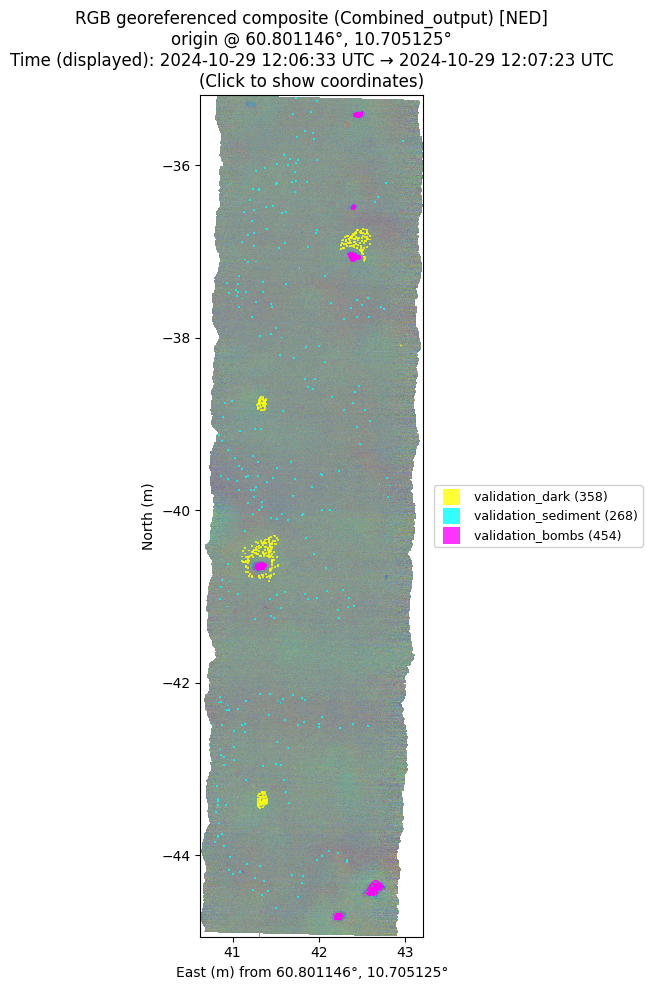

In [15]:
# Plot validation ROIs
%matplotlib inline

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection=validation_rois,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Train SVM with Cross-Validation

In [16]:
# Train SVM with spatial cross-validation - NORMALIZED + SMOOTHED SPECTRAL MODE
cv_results = cube.train_svm_with_cv(
    training_rois=training_rois,
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    wavelength_range=None,  # ✅ REMOVED - data already preprocessed in memory!
    cv_folds=5,
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    add_brightness_feature=False,
    use_intensity_only=False,  # Use full normalized+smoothed spectrum
    quiet=False,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY (NORMALIZED + SMOOTHED)")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used:")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

🤖 SVM TRAINING WITH CROSS-VALIDATION
💡 MODE: Standard spectral classification

�📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']

🔍 Filtering ROI pixels...
   training_dark: 364 pixels (rejected 0 inside segment)
   training_sediment: 397 pixels (rejected 1 inside segment)
   training_bombs: 201 pixels (rejected 0 inside segment)

✅ Training data: 962 pixels, 108 features
   Features: 108 wavelengths
   Kept (outside segment): 962
   Rejected (inside segment): 1

🔬 Creating spatial groups for CV...
   Settings: closing_radius=3, min_group_size=20
   Sediment grid: 100(slit) × 200(track) px, min=10
   training_dark: 364 pixels → 6 groups via connected_components
      dark#A: 119 pixels
      dark#B: 50 pixels
      dark#C: 37 pixels
      dark#D: 29 pixels
      dark#E: 51 pixels
      dark#F: 78 pixels
      Merged small tile (11, 2) (9 px) → neighbor tile
      Merg

💡 Interactive mode: Click on the plot to display coordinates


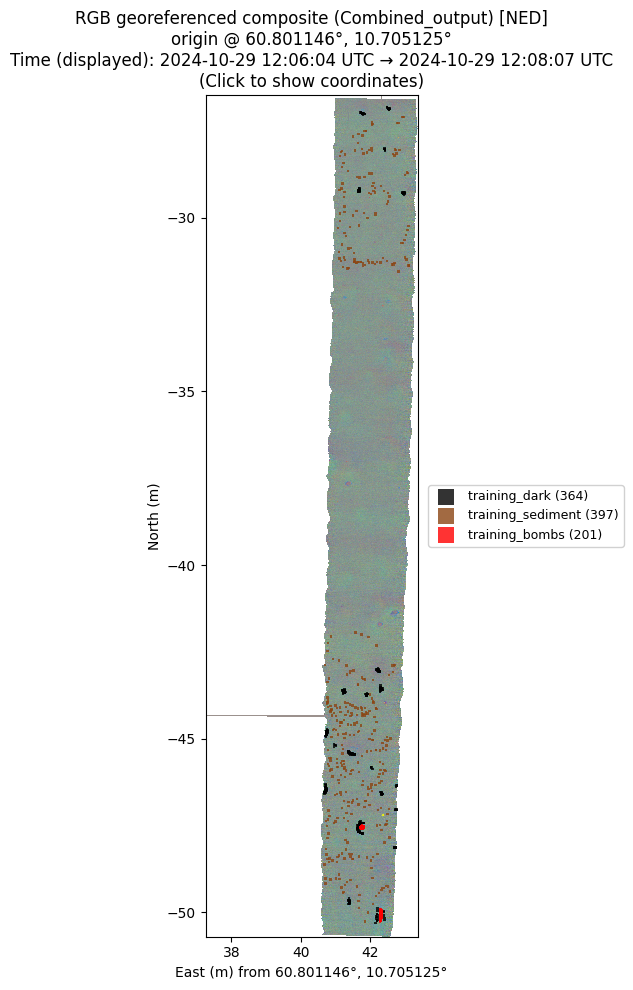

In [17]:
# Visualize filtered training ROIs
cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results["filtered_training_rois"],
    roi_marker_size=3,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

💡 Interactive mode: Click on the plot to display coordinates


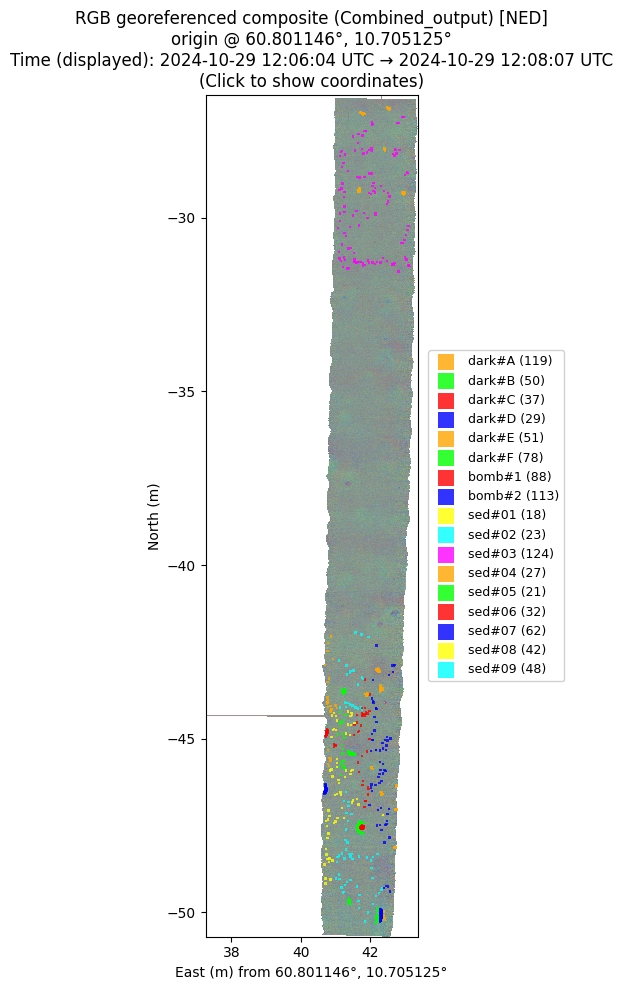


📊 Spatial Groups Created:
   bomb#1: 88 pixels
   bomb#2: 113 pixels
   dark#A: 119 pixels
   dark#B: 50 pixels
   dark#C: 37 pixels
   dark#D: 29 pixels
   dark#E: 51 pixels
   dark#F: 78 pixels
   sed#01: 18 pixels
   sed#02: 23 pixels
   sed#03: 124 pixels
   sed#04: 27 pixels
   sed#05: 21 pixels
   sed#06: 32 pixels
   sed#07: 62 pixels
   sed#08: 42 pixels
   sed#09: 48 pixels


In [18]:
# Plot spatial groups created during training
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results["spatial_groups_roi_collection"],
        roi_marker_size=3,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
    )

    # Print group info
    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")
else:
    print(
        "⚠️ No spatial groups found in cv_results. Training may not have used spatial clustering."
    )

📊 SPATIAL GROUPS SPECTRUM PLOT
Current wavelength array length: 108
Wavelength range: 490.2 - 679.4 nm
Data shape: (2462, 968, 108)

⚠️  This plot shows the PREPROCESSED data that the SVM trained on:
   ✅ Bad wavelengths interpolated
   ✅ Cropped to 490-680 nm
   ✅ Smoothed (MA, window=10)
   ✅ L2 normalized



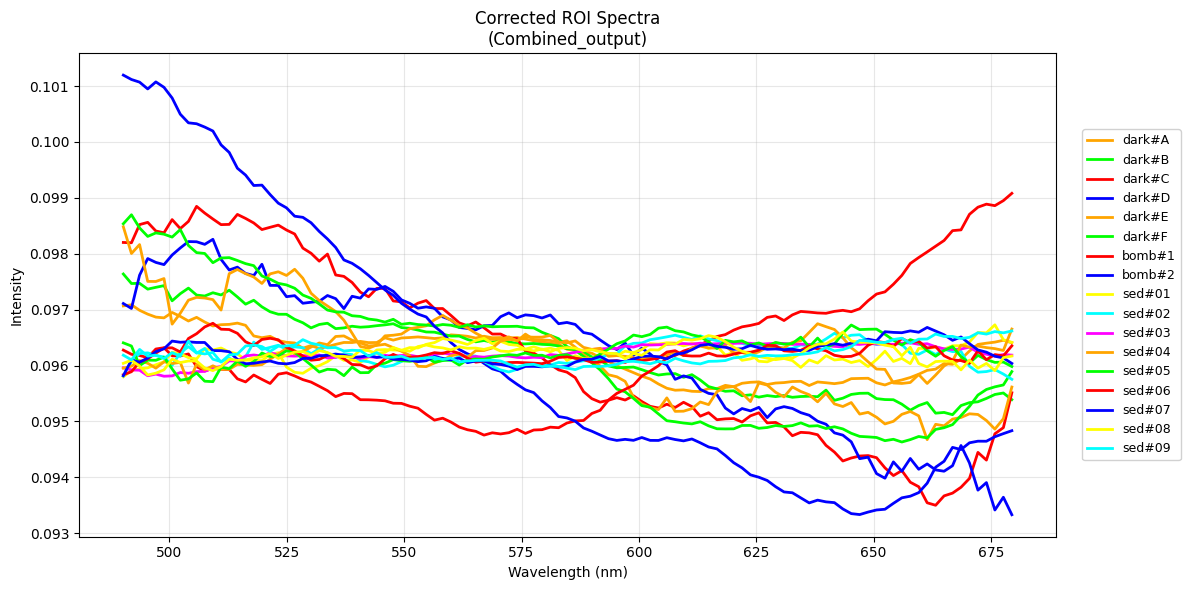

In [19]:
# Plot spectra for all spatial groups (PREPROCESSED DATA)
# ⚠️ CRITICAL: These spectra come from data_corrected which has been:
# 1. Interpolated (bad wavelengths [64, 107, 138] fixed in ORIGINAL 224-band cube)
# 2. Cropped (490-680 nm → now only 108 bands)
# 3. Smoothed (moving average, window=10)
# 4. Normalized (L2 unit-length)

if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    print("=" * 60)
    print("📊 SPATIAL GROUPS SPECTRUM PLOT")
    print("=" * 60)
    print(f"Current wavelength array length: {len(cube.wavelengths)}")
    print(
        f"Wavelength range: {cube.wavelengths[0]:.1f} - {cube.wavelengths[-1]:.1f} nm"
    )
    print(f"Data shape: {cube.data_corrected.shape}")
    print()
    print("⚠️  This plot shows the PREPROCESSED data that the SVM trained on:")
    print("   ✅ Bad wavelengths interpolated")
    print("   ✅ Cropped to 490-680 nm")
    print("   ✅ Smoothed (MA, window=10)")
    print("   ✅ L2 normalized")
    print("=" * 60)
    print()

    # Temporarily add spatial groups to ROI collection
    original_rois = cube.roi_collection.copy()
    cube.roi_collection.update(cv_results["spatial_groups_roi_collection"])

    # Plot spectra - MUST NOT apply any additional processing!
    cube.plot_spectrum(
        roi_names=list(cv_results["spatial_groups_roi_collection"].keys()),
        use_corrected=True,  # ✅ Uses preprocessed data_corrected
        wavelength_range=None,  # ❌ Do NOT filter again!
        wavelength_smoothing=1,  # ❌ Do NOT smooth again!
        interpolate_wavelengths=None,  # ❌ Do NOT interpolate again!
        normalize_method=None,  # ❌ Do NOT normalize again!
        legend_loc="outside",
        use_inline_labels=False,
        show_std=False,
    )

    # Restore original ROI collection
    cube.roi_collection = original_rois
else:
    print("⚠️ No spatial groups found in cv_results.")

## STEP 1: Classification (outputs classified_* with confidence analysis)

**NEW WORKFLOW:** Classification with confidence threshold + merge
1. ✅ Run `classify_segment` with `confidence_threshold=0.5` → 4 classes
2. ✅ Analyze uncertainty (optional diagnostic cells below)
3. ✅ Merge unknown pixels to sediment → 3 classes
4. ✅ Continue to STEP 2 (filtering)

This approach allows you to:
- Identify and visualize uncertain predictions
- Still use the standard 3-class pipeline
- Only run classification ONCE

## 🎲 Optional: Test Confidence Threshold

**New feature: Confidence-based classification**
- SVM now trained with `probability=True` (slightly slower but gives confidence scores)
- Can set `confidence_threshold` to reject uncertain predictions
- Pixels with `max_probability < threshold` become `"classified_unknown"`
- Useful to identify ambiguous boundary regions between classes

**Try different thresholds:**
- `None` (default): All pixels classified, no "unknown" class
- `0.5`: Moderate threshold - reject if all 3 classes < 50%
- `0.7`: Strict threshold - only keep high-confidence predictions

In [20]:
# TEST: Classify with confidence threshold = 0.5
# (Pixels with max_prob < 0.5 become "classified_unknown")
print("🎲 TESTING CONFIDENCE THRESHOLD = 0.5")
print("=" * 60)

classification_results_with_conf = cube.classify_segment(
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    use_corrected=True,
    confidence_threshold=0.5,  # ✅ NEW: Reject low-confidence pixels
    quiet=False,
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results_with_conf['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results_with_conf["class_names"]:
    count = np.sum(classification_results_with_conf["classification_map"] == class_name)
    percentage = (
        100.0 * count / classification_results_with_conf["classification_map"].size
    )
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")

🎲 TESTING CONFIDENCE THRESHOLD = 0.5
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...


   Classifying: 100%|█████████████████████████████████| 959288/959288 [02:16<00:00, 7010.74pixels/s]




🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 35077 (3.7%)
   Confidence range: [0.333, 0.988]
   ✅ Classification complete in 137.43 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 29357 pixels (3.1%)
   classified_dark: 133071 pixels (13.9%)
   classified_sediment: 761783 pixels (79.4%)
   classified_unknown: 35077 pixels (3.7%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes: ['classified_bombs', 'classified_dark', 'classified_sediment', 'classified_unknown']

📊 Pixel counts:
   classified_bombs: 29357 pixels (3.1%)
   classified_dark: 133071 pixels (13.9%)
   classified_sediment: 761783 pixels (79.4%)
   classified_unknown: 35077 pixels (3.7%)

📊 Classification distribution (before filtering):
   classified_bombs: 29357 pixels (3.1%)
   classified_dark: 133071 pixels (13.9%)
   classified_sediment: 761783 pixels (79.4%)
   classified_unknown: 35077 pixels (3.7%)

✅ Classification and validation co

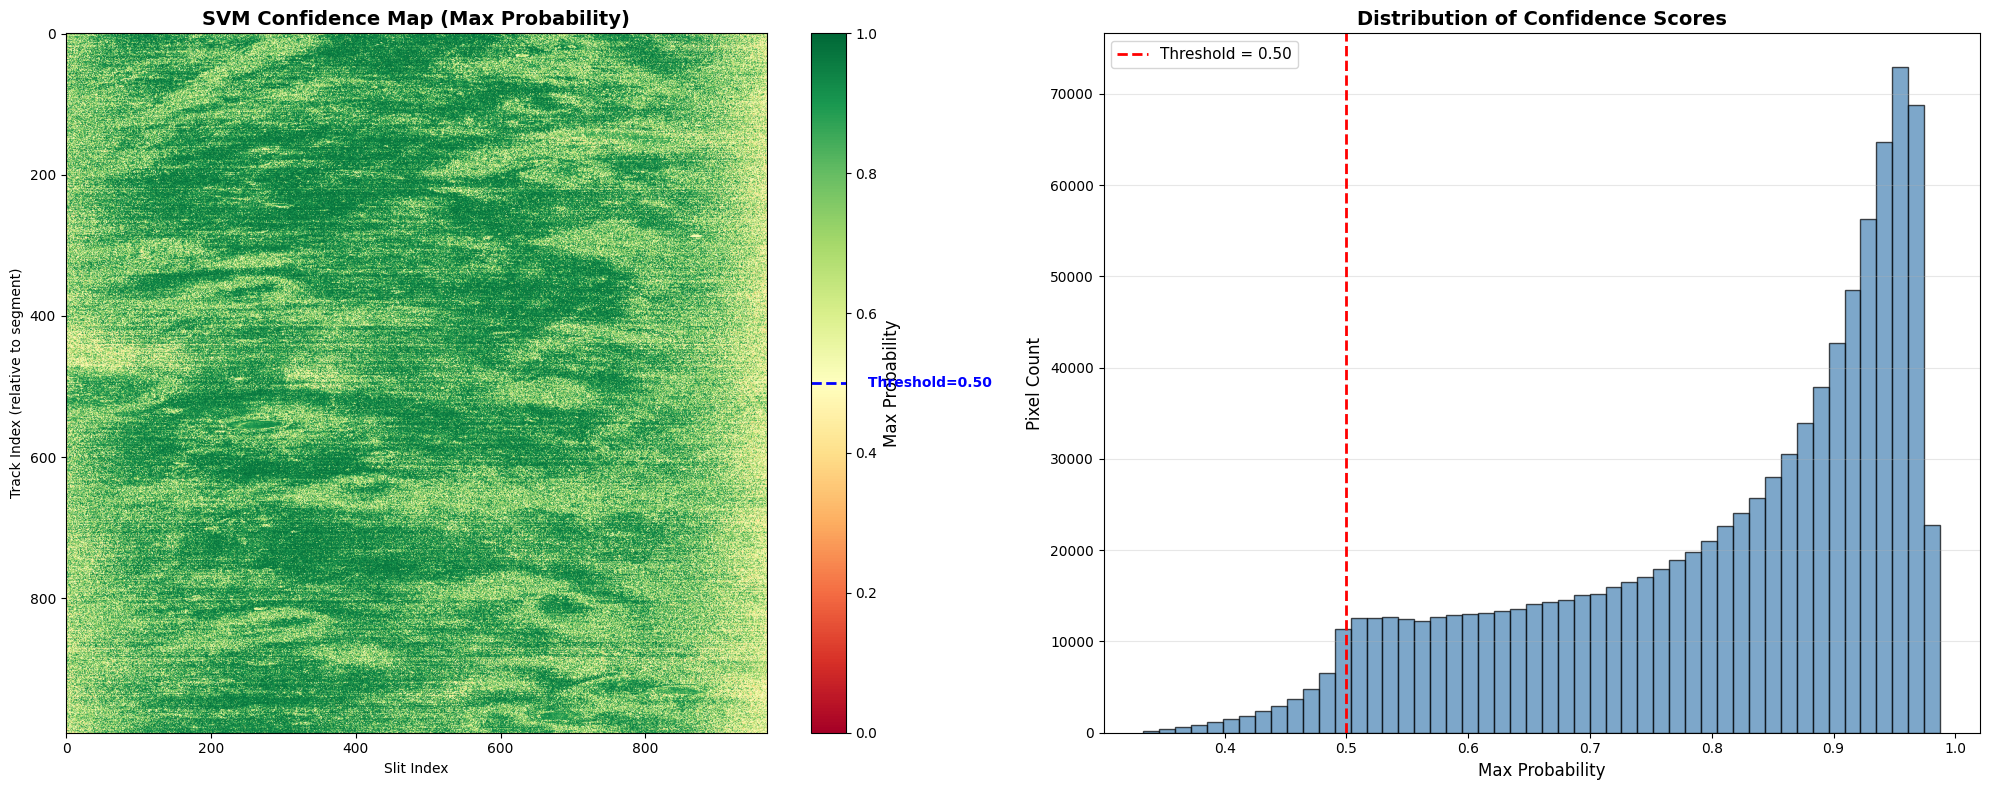


📊 Confidence Statistics:
   Mean confidence: 0.806
   Std confidence:  0.150
   Min confidence:  0.333
   Max confidence:  0.988


In [21]:
# Plot confidence map (heatmap showing SVM certainty)
import matplotlib.pyplot as plt

confidence_map = classification_results_with_conf["confidence_map"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left: Confidence heatmap
im1 = ax1.imshow(confidence_map, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax1.set_title("SVM Confidence Map (Max Probability)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Slit Index")
ax1.set_ylabel("Track Index (relative to segment)")
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Max Probability", fontsize=12)

# Add threshold line to colorbar
threshold = 0.5
cbar1.ax.axhline(y=threshold, color="blue", linewidth=2, linestyle="--")
cbar1.ax.text(
    1.5,
    threshold,
    f" Threshold={threshold:.2f}",
    va="center",
    fontsize=10,
    color="blue",
    fontweight="bold",
)

# Right: Histogram of confidence values
ax2.hist(
    confidence_map.flatten(), bins=50, color="steelblue", alpha=0.7, edgecolor="black"
)
ax2.axvline(
    x=threshold,
    color="red",
    linewidth=2,
    linestyle="--",
    label=f"Threshold = {threshold:.2f}",
)
ax2.set_xlabel("Max Probability", fontsize=12)
ax2.set_ylabel("Pixel Count", fontsize=12)
ax2.set_title("Distribution of Confidence Scores", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Confidence Statistics:")
print(f"   Mean confidence: {confidence_map.mean():.3f}")
print(f"   Std confidence:  {confidence_map.std():.3f}")
print(f"   Min confidence:  {confidence_map.min():.3f}")
print(f"   Max confidence:  {confidence_map.max():.3f}")

📊 Plotting classification with confidence threshold...
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment', 'classified_unknown']
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment', 'classified_unknown']
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


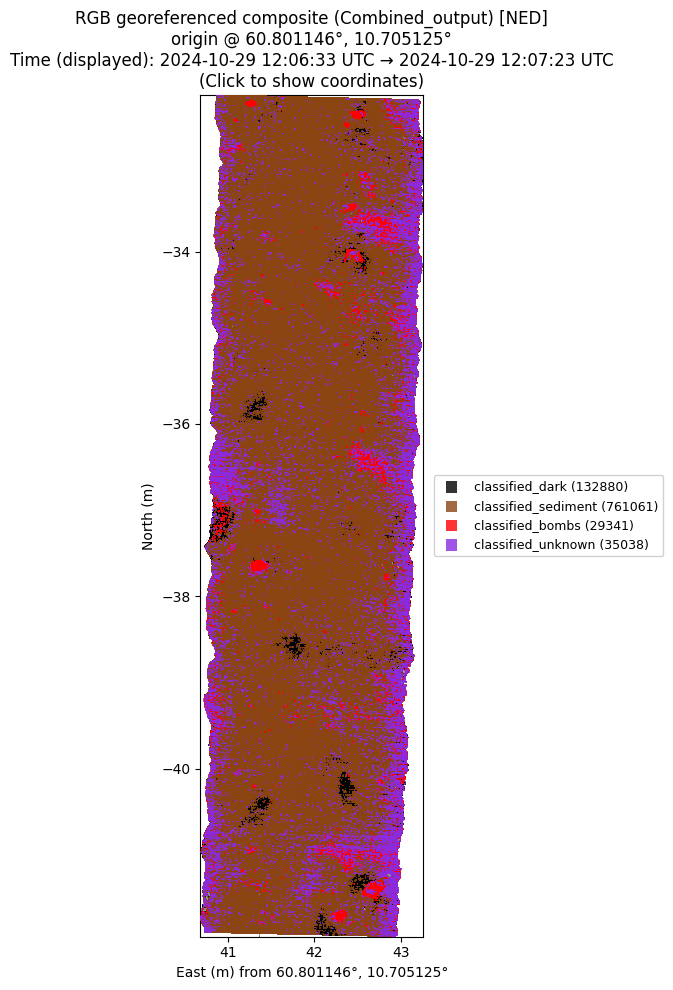


💡 The 'classified_unknown' pixels (if any) show where the SVM is uncertain!
   These are typically:
   - Boundary pixels between classes
   - Noisy or ambiguous spectra
   - Transition zones (e.g., sediment → dark)


In [22]:
# Plot classification with unknown pixels highlighted
print("📊 Plotting classification with confidence threshold...")

classification_rois_with_conf = {}
for class_name in classification_results_with_conf["class_names"]:
    mask = classification_results_with_conf["classification_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois_with_conf[class_name] = pixels

print(f"ROIs created: {list(classification_rois_with_conf.keys())}")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=classification_rois_with_conf,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

print("\n💡 The 'classified_unknown' pixels (if any) show where the SVM is uncertain!")
print("   These are typically:")
print("   - Boundary pixels between classes")
print("   - Noisy or ambiguous spectra")
print("   - Transition zones (e.g., sediment → dark)")

## 🔄 Merge Unknown to Sediment (for pipeline compatibility)

Now merge `classified_unknown` pixels into `classified_sediment` to create a 3-class map compatible with the standard pipeline (filtering → merge → validation).

In [23]:
# Merge unknown pixels into sediment class
# This converts 4-class output to 3-class output for standard pipeline
classification_results = cube.merge_unknown_to_sediment(
    classification_results_with_conf, quiet=False
)

print(f"\n✅ Ready for standard pipeline!")
print(
    f"   Classification now has {len(classification_results['class_names'])} classes: {classification_results['class_names']}"
)

🔀 MERGING UNKNOWN PIXELS TO SEDIMENT

📊 Pixel counts BEFORE merge:
   classified_sediment: 761783
   classified_unknown:  35077

📊 Pixel counts AFTER merge:
   classified_sediment: 796860 (+35077)

✅ Merge complete! Classes: ['classified_bombs', 'classified_dark', 'classified_sediment']

✅ Ready for standard pipeline!
   Classification now has 3 classes: ['classified_bombs', 'classified_dark', 'classified_sediment']


📊 Plotting merged 3-class classification map...
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment']
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment']
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


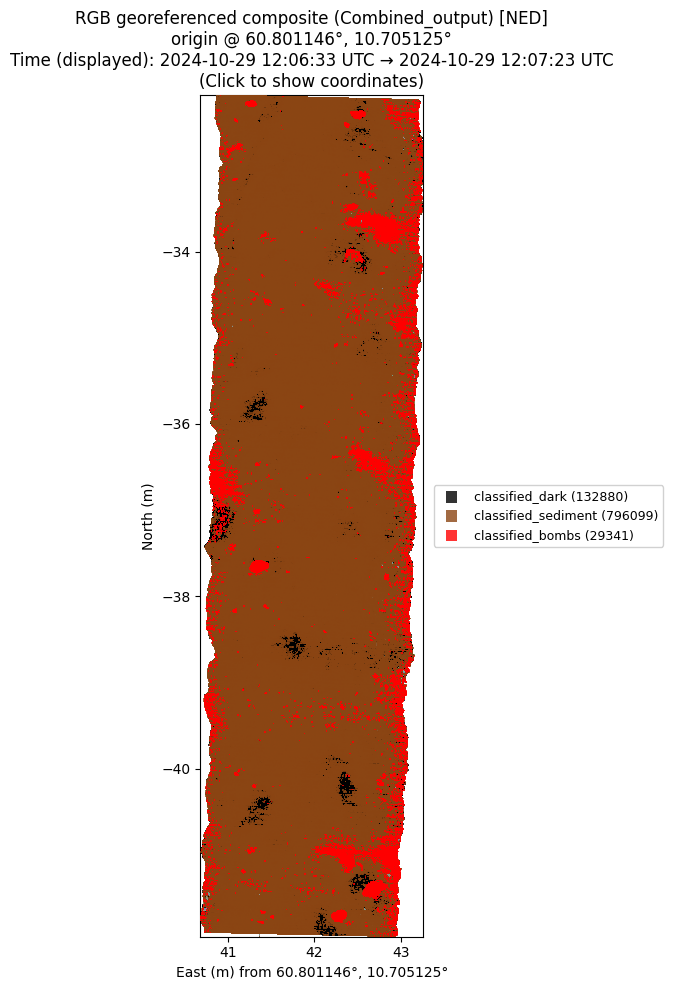


💡 This 3-class map can now be used in the standard pipeline (filtering → merge → validation)


In [24]:
# Plot the merged 3-class classification (unknown pixels now part of sediment)
print("📊 Plotting merged 3-class classification map...")

classification_rois_merged = {}
for class_name in classification_results["class_names"]:
    mask = classification_results["classification_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois_merged[class_name] = pixels

print(f"ROIs created: {list(classification_rois_merged.keys())}")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=classification_rois_merged,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

print(
    "\n💡 This 3-class map can now be used in the standard pipeline (filtering → merge → validation)"
)

## ⚠️ DEPRECATED: Old Classification Section

**This section is NO LONGER NEEDED!**

The workflow now uses:
1. Classification with confidence threshold (above) → 4 classes
2. Merge unknown to sediment (above) → 3 classes  
3. Continue to STEP 2 below

You can delete/skip this section. It's kept here for reference only.

In [25]:
# # Classify segment - outputs classified_bombs, classified_dark, classified_sediment
# print("🎯 STEP 1: CLASSIFICATION")
# print("=" * 60)

# classification_results = cube.classify_segment(
#     segment_start=config.UHI_TRACK_RANGE_5[0],
#     segment_end=config.UHI_TRACK_RANGE_5[1],
#     use_corrected=True,
#     quiet=False,
# )

# print(f"\n✅ Classification complete!")
# print(f"   Classes: {classification_results['class_names']}")
# print(f"\n📊 Pixel counts:")
# for class_name in classification_results["class_names"]:
#     count = np.sum(classification_results["classification_map"] == class_name)
#     print(f"   {class_name}: {count} pixels")

In [26]:
# # Plot classification (3 classes)
# print("📊 Plotting classification map (3 classes)...")

# classification_rois = {}
# for class_name in classification_results["class_names"]:
#     mask = classification_results["classification_map"] == class_name
#     rows, cols = np.where(mask)
#     pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
#     if len(pixels) > 0:
#         classification_rois[class_name] = pixels

# print(f"ROIs created: {list(classification_rois.keys())}")

# cube.plot_georef(
#     use_corrected=True,
#     coordinate_system="NED",
#     track_start=config.UHI_TRACK_RANGE_5[0],
#     track_end=config.UHI_TRACK_RANGE_5[1],
#     figsize=(40, 10),
#     roi_collection=classification_rois,
#     roi_marker_size=1,
#     roi_legend_loc="outside",
#     roi_marker_edgewidth=0,
#     roi_legend_markersize=50,
# )

## STEP 2: Filtering (creates filtered_*)

In [27]:
# Apply filtering - creates filtered_bombs and filtered_dark
print("\n🧹 STEP 2: FILTERING")
print("=" * 60)

filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,
    filter_dark=True,
    filter_sediment=False,
    min_area_px=10,
    connectivity=8,
    morph_close_radius=0,  # Disabled
    morph_open_radius=0,  # Disabled
    merge_proximity_px=0,
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   All classes after filtering: {filtering_results['all_classes']}")


🧹 STEP 2: FILTERING
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['classified_bombs', 'classified_dark']
   Connectivity: 8
   Min area: 10 pixels
   Morph close radius: 0 (disabled)
   Morph open radius: 0 (disabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering classified_bombs (bomb)...
      Found 7911 connected components
      Kept: 235 components (16404 pixels)
      Removed: 7676 components (12953 pixels)
      ✂️  Reclassified 12953 pixels as filtered_bombs
      Final: 16404 pixels (12953 removed, 44.1%)

   🔍 Filtering classified_dark (dark)...
      Found 25041 connected components
      Kept: 235 components (16404 pixels)
      Removed: 7676 components (12953 pixels)
      ✂️  Reclassified 12953 pixels as filtered_bombs
      Final: 16404 pixels (12953 removed, 44.1%)

   🔍 Filtering classified_dark (dark)...
      Found 25041 connected components
      Kept: 1065 components (89076 pixels)
      Removed: 23976 components (43

In [28]:
# ==================== TEST: DIAGNOSTIC - Check filtering behavior ====================
# TEST: Let's see what's happening with dark vs bombs filtering
# This will show us the actual connected components found for each class

from scipy.ndimage import label

classification_map = classification_results["classification_map"]
class_names = classification_results["class_names"]

print("=" * 80)
print("TEST: FILTERING DIAGNOSTIC - Analyzing connected components BEFORE filtering")
print("=" * 80)

# Analyze bombs
if "classified_bombs" in class_names:
    bombs_mask = (classification_map == "classified_bombs").astype(np.uint8)
    structure = np.ones((3, 3), dtype=int)  # 8-connectivity
    labeled_bombs, n_bombs = label(bombs_mask, structure=structure)

    # Count components by size
    bomb_sizes = []
    for comp_id in range(1, n_bombs + 1):
        size = np.sum(labeled_bombs == comp_id)
        bomb_sizes.append(size)

    bomb_sizes_sorted = sorted(bomb_sizes)
    n_small_bombs = sum(1 for s in bomb_sizes if s < 10)

    print(f"\n🔴 BOMBS:")
    print(f"   Total pixels: {np.sum(bombs_mask)}")
    print(f"   Connected components: {n_bombs}")
    print(f"   Components < 10 px: {n_small_bombs} (will be filtered)")
    print(
        f"   Component sizes: min={min(bomb_sizes) if bomb_sizes else 0}, max={max(bomb_sizes) if bomb_sizes else 0}, median={np.median(bomb_sizes) if bomb_sizes else 0:.0f}"
    )
    if len(bomb_sizes) <= 20:
        print(f"   All sizes: {bomb_sizes_sorted}")
    else:
        print(f"   Smallest 10: {bomb_sizes_sorted[:10]}")
        print(f"   Largest 10: {bomb_sizes_sorted[-10:]}")

# Analyze dark
if "classified_dark" in class_names:
    dark_mask = (classification_map == "classified_dark").astype(np.uint8)
    structure = np.ones((3, 3), dtype=int)  # 8-connectivity
    labeled_dark, n_dark = label(dark_mask, structure=structure)

    # Count components by size
    dark_sizes = []
    for comp_id in range(1, n_dark + 1):
        size = np.sum(labeled_dark == comp_id)
        dark_sizes.append(size)

    dark_sizes_sorted = sorted(dark_sizes)
    n_small_dark = sum(1 for s in dark_sizes if s < 10)

    print(f"\n⚫ DARK:")
    print(f"   Total pixels: {np.sum(dark_mask)}")
    print(f"   Connected components: {n_dark}")
    print(f"   Components < 10 px: {n_small_dark} (SHOULD be filtered)")
    print(
        f"   Component sizes: min={min(dark_sizes) if dark_sizes else 0}, max={max(dark_sizes) if dark_sizes else 0}, median={np.median(dark_sizes) if dark_sizes else 0:.0f}"
    )
    if len(dark_sizes) <= 20:
        print(f"   All sizes: {dark_sizes_sorted}")
    else:
        print(f"   Smallest 10: {dark_sizes_sorted[:10]}")
        print(f"   Largest 10: {dark_sizes_sorted[-10:]}")

print("\n" + "=" * 80)
print("TEST: If you see many small dark components but they're NOT being filtered,")
print("      then there's a bug in the _post_classification_filtering function!")
print("=" * 80)

TEST: FILTERING DIAGNOSTIC - Analyzing connected components BEFORE filtering

🔴 BOMBS:
   Total pixels: 29357
   Connected components: 7911
   Components < 10 px: 7676 (will be filtered)
   Component sizes: min=1, max=2716, median=1
   Smallest 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
   Largest 10: [323, 394, 588, 733, 734, 857, 872, 1317, 1662, 2716]

🔴 BOMBS:
   Total pixels: 29357
   Connected components: 7911
   Components < 10 px: 7676 (will be filtered)
   Component sizes: min=1, max=2716, median=1
   Smallest 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
   Largest 10: [323, 394, 588, 733, 734, 857, 872, 1317, 1662, 2716]

⚫ DARK:
   Total pixels: 133071
   Connected components: 25041
   Components < 10 px: 23976 (SHOULD be filtered)
   Component sizes: min=1, max=11366, median=1
   Smallest 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
   Largest 10: [2624, 2826, 2868, 2888, 3393, 3512, 3642, 3729, 6197, 11366]

TEST: If you see many small dark components but they're NOT being filtered,
      then there'

📊 Plotting filtered map (5 classes: classified_* + filtered_*)...
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment', 'filtered_bombs', 'filtered_dark']

📊 Pixel counts:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pixels
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment', 'filtered_bombs', 'filtered_dark']

📊 Pixel counts:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pixels
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


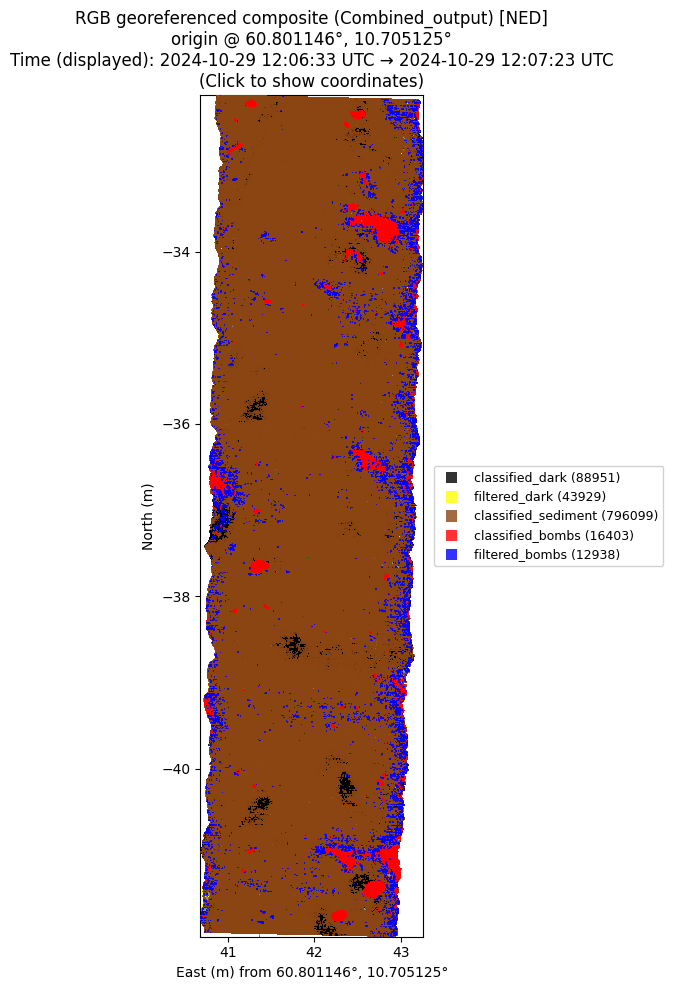


💡 NOTE: filtered_* classes plotted on TOP so they're visible!


In [29]:
# Plot filtered map (5 classes!)
print("📊 Plotting filtered map (5 classes: classified_* + filtered_*)...")

# Create ROI collection with filtered_* classes LAST (plotted on top)
filtered_rois = {}

# First add classified_* classes (will be on bottom)
for class_name in filtering_results["all_classes"]:
    if class_name.startswith("classified_"):
        mask = filtering_results["filtered_map"] == class_name
        rows, cols = np.where(mask)
        pixels = [
            (col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)
        ]
        if len(pixels) > 0:
            filtered_rois[class_name] = pixels

# Then add filtered_* classes (will be plotted on top, visible)
for class_name in filtering_results["all_classes"]:
    if class_name.startswith("filtered_"):
        mask = filtering_results["filtered_map"] == class_name
        rows, cols = np.where(mask)
        pixels = [
            (col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)
        ]
        if len(pixels) > 0:
            filtered_rois[class_name] = pixels

print(f"ROIs created: {list(filtered_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(filtered_rois.keys()):
    print(f"   {class_name}: {len(filtered_rois[class_name])} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=filtered_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

print("\n💡 NOTE: filtered_* classes plotted on TOP so they're visible!")

In [30]:
# ==================== TEST: DIAGNOSTIC - Check filtering results ====================
# TEST: Compare what was actually filtered

filtered_map = filtering_results["filtered_map"]
all_classes = filtering_results["all_classes"]

print("=" * 80)
print("TEST: FILTERING DIAGNOSTIC - Results AFTER filtering")
print("=" * 80)

# Count filtered pixels
for class_name in all_classes:
    count = np.sum(filtered_map == class_name)
    percentage = 100.0 * count / filtered_map.size
    print(f"{class_name}: {count} pixels ({percentage:.2f}%)")

# Specifically check filtered classes
filtered_bombs_count = (
    np.sum(filtered_map == "filtered_bombs") if "filtered_bombs" in all_classes else 0
)
filtered_dark_count = (
    np.sum(filtered_map == "filtered_dark") if "filtered_dark" in all_classes else 0
)

print("\n📊 FILTERING EFFECTIVENESS:")
print(f"   Filtered bombs: {filtered_bombs_count} pixels removed")
print(f"   Filtered dark: {filtered_dark_count} pixels removed")

if filtered_bombs_count > 0 and filtered_dark_count == 0:
    print("\n⚠️  WARNING: Bombs are being filtered but dark is NOT!")
    print("   This confirms there's a bug in the filtering function.")
elif filtered_dark_count > 0:
    print("\n✅ Both classes are being filtered.")
else:
    print("\n❌ Neither class is being filtered effectively.")

print("=" * 80)

TEST: FILTERING DIAGNOSTIC - Results AFTER filtering
classified_bombs: 16404 pixels (1.71%)
classified_dark: 89076 pixels (9.29%)
classified_sediment: 796860 pixels (83.07%)
filtered_bombs: 12953 pixels (1.35%)
filtered_dark: 43995 pixels (4.59%)

📊 FILTERING EFFECTIVENESS:
   Filtered bombs: 12953 pixels removed
   Filtered dark: 43995 pixels removed

✅ Both classes are being filtered.


In [31]:
# ==================== TEST: DIAGNOSTIC - Check color mapping ====================
# TEST: The issue might be that filtered_dark and classified_dark have similar colors!

print("=" * 80)
print("TEST: COLOR DIAGNOSTIC - Check if filtered_dark is visible")
print("=" * 80)

# Let's see what colors are being assigned
print("\n📊 Classes in filtered map:")
for class_name in sorted(filtering_results["all_classes"]):
    count = np.sum(filtering_results["filtered_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

print("\n💡 HYPOTHESIS:")
print("   If filtered_dark and classified_dark have similar colors (both black/dark),")
print("   then the filtered dark pixels will be INVISIBLE in the plot even though")
print("   they ARE being filtered correctly!")
print("\n   Solution: Change color scheme or plot only filtered_* classes to verify.")
print("=" * 80)

TEST: COLOR DIAGNOSTIC - Check if filtered_dark is visible

📊 Classes in filtered map:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pixels

💡 HYPOTHESIS:
   If filtered_dark and classified_dark have similar colors (both black/dark),
   then the filtered dark pixels will be INVISIBLE in the plot even though
   they ARE being filtered correctly!

   Solution: Change color scheme or plot only filtered_* classes to verify.


TEST: Plotting ONLY filtered_* classes (what was removed)
Plotting: ['filtered_bombs', 'filtered_dark']
filtered_bombs: 12953 pixels
filtered_dark: 43995 pixels
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


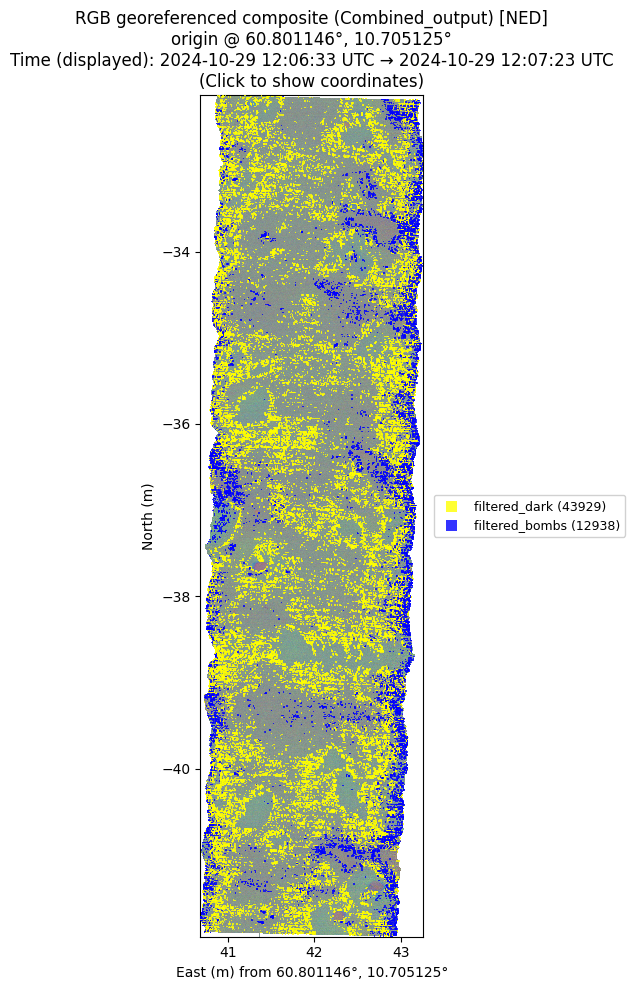


💡 If you see scattered dark pixels here, then filtering IS working!
   The issue is just that filtered_dark color is too similar to classified_dark.


In [32]:
# ==================== TEST: PLOT - Show ONLY filtered_* classes ====================
# TEST: Plot only filtered_bombs and filtered_dark to see if they're really there

print("=" * 80)
print("TEST: Plotting ONLY filtered_* classes (what was removed)")
print("=" * 80)

filtered_only_rois = {}
for class_name in ["filtered_bombs", "filtered_dark"]:
    if class_name in filtering_results["all_classes"]:
        mask = filtering_results["filtered_map"] == class_name
        rows, cols = np.where(mask)
        pixels = [
            (col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)
        ]
        if len(pixels) > 0:
            filtered_only_rois[class_name] = pixels

print(f"Plotting: {list(filtered_only_rois.keys())}")
print(f"filtered_bombs: {len(filtered_only_rois.get('filtered_bombs', []))} pixels")
print(f"filtered_dark: {len(filtered_only_rois.get('filtered_dark', []))} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=filtered_only_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

print("\n💡 If you see scattered dark pixels here, then filtering IS working!")
print(
    "   The issue is just that filtered_dark color is too similar to classified_dark."
)
print("=" * 80)

## STEP 3: Merge to create new_sediment

In [33]:
# Merge filtered classes into new_sediment
print("\n🔀 STEP 3: MERGE FILTERED CLASSES")
print("=" * 60)

merge_results = cube.merge_filtered_to_sediment(
    filtered_map=filtering_results["filtered_map"],
    quiet=False,
)

print(f"\n✅ Merge complete!")
print(f"   Final classes for validation: {merge_results['class_names']}")


🔀 STEP 3: MERGE FILTERED CLASSES
🔀 MERGING FILTERED CLASSES TO SEDIMENT

📊 Before merge:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pixels

🔀 Merged into new_sediment:
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pixels
   ─────────────────────────
   Total: 853808 pixels

📊 After merge (3 classes for validation):
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   new_sediment: 853808 pixels

✅ Merge complete!
   Final classes for validation: ['classified_bombs', 'classified_dark', 'new_sediment']

📊 Before merge:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pixels

🔀 Merged into new_sediment:
   classified_sediment: 796860 pixels
   filtered_bombs: 12953 pixels
   filtered_dark: 43995 pi

📊 Plotting validation map (3 classes)...
ROIs created: ['classified_bombs', 'classified_dark', 'new_sediment']

📊 Pixel counts:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   new_sediment: 853808 pixels
ROIs created: ['classified_bombs', 'classified_dark', 'new_sediment']

📊 Pixel counts:
   classified_bombs: 16404 pixels
   classified_dark: 89076 pixels
   new_sediment: 853808 pixels
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


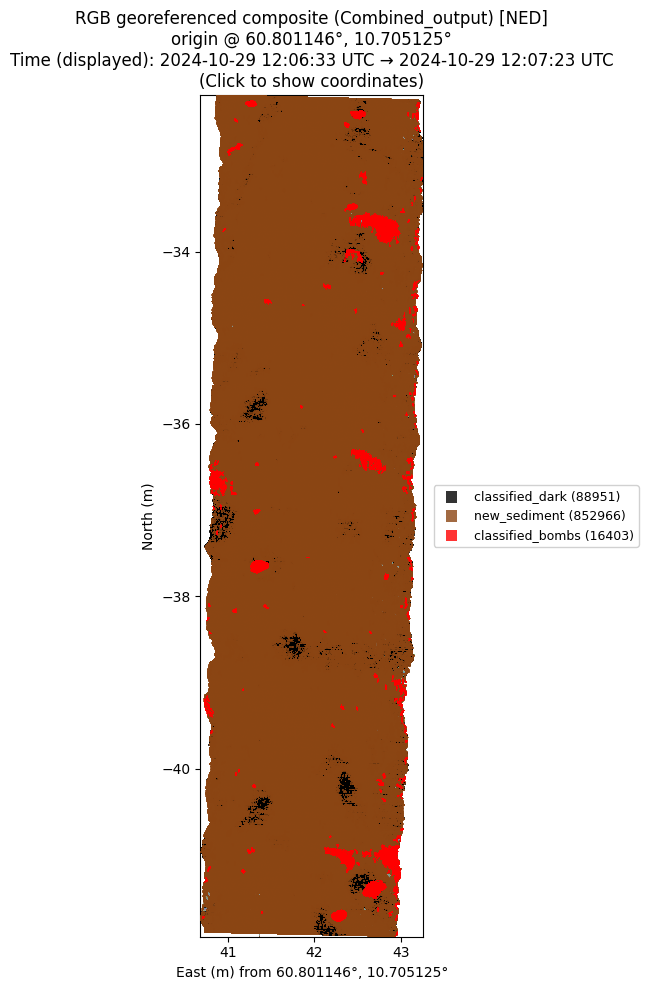

In [34]:
# Plot validation map (3 classes)
print("📊 Plotting validation map (3 classes)...")

validation_map_rois = {}
for class_name in merge_results["class_names"]:
    mask = merge_results["validation_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        validation_map_rois[class_name] = pixels

print(f"ROIs created: {list(validation_map_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(validation_map_rois.keys()):
    print(f"   {class_name}: {len(validation_map_rois[class_name])} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=validation_map_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## STEP 4: Validation

In [35]:
# Validate using the 3-class map
print("\n📊 STEP 4: VALIDATION")
print("=" * 60)

validation_results = cube.validate_classification(
    classification_map=merge_results["validation_map"],
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "validation_sediment": "new_sediment",
        "validation_dark": "classified_dark",
        "validation_bombs": "classified_bombs",
    },
    quiet=False,
)

# Print summary
if validation_results:
    print(f"\n" + "=" * 60)
    print(f"📊 VALIDATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results:")
    for class_name in merge_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results['precision_per_class'][class_name]:.3f}"
        )
        print(f"  Recall:    {validation_results['recall_per_class'][class_name]:.3f}")
        print(f"  F1 Score:  {validation_results['f1_per_class'][class_name]:.3f}")
        print(
            f"  Support:   {validation_results['support_per_class'][class_name]} pixels"
        )


📊 STEP 4: VALIDATION
📊 CLASSIFICATION VALIDATION

   Classes in classification: ['classified_bombs', 'classified_dark', 'new_sediment']
   Classes in validation: ['classified_bombs', 'classified_dark', 'new_sediment']

📈 Validation Results:
   Overall Accuracy: 0.694

   Per-Class Metrics:
   classified_bombs: P=0.991, R=0.760, F1=0.860, Support=454
   classified_dark: P=0.940, R=0.394, F1=0.555, Support=358
   new_sediment: P=0.452, R=0.981, F1=0.619, Support=268

📊 VALIDATION RESULTS
Overall Accuracy: 0.694

📋 Per-Class Results:

classified_bombs:
  Precision: 0.991
  Recall:    0.760
  F1 Score:  0.860
  Support:   454 pixels

classified_dark:
  Precision: 0.940
  Recall:    0.394
  F1 Score:  0.555
  Support:   358 pixels

new_sediment:
  Precision: 0.452
  Recall:    0.981
  F1 Score:  0.619
  Support:   268 pixels

   Classes in classification: ['classified_bombs', 'classified_dark', 'new_sediment']
   Classes in validation: ['classified_bombs', 'classified_dark', 'new_sediment'

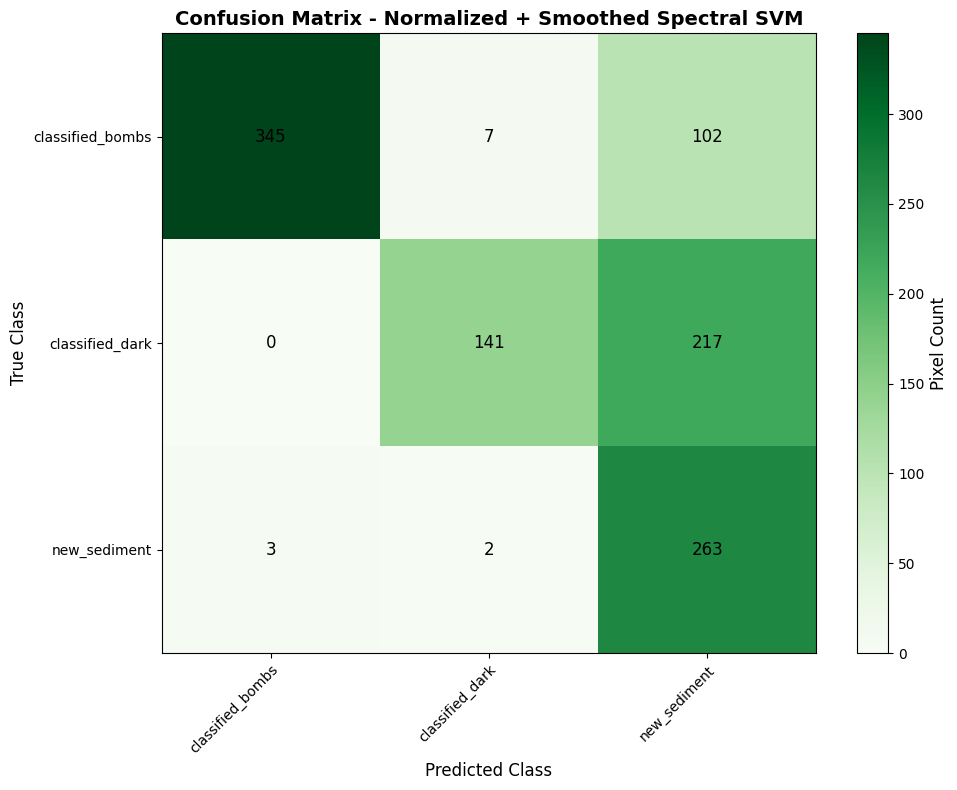


📊 Confusion Matrix (Normalized by True Class - Row %):
                        classified_bombs     classified_dark        new_sediment
--------------------------------------------------------------------------------
classified_bombs                   76.0%                1.5%               22.5%
classified_dark                     0.0%               39.4%               60.6%
new_sediment                        1.1%                0.7%               98.1%


In [36]:
# Plot confusion matrix
if validation_results:
    import matplotlib.pyplot as plt

    cm = validation_results["confusion_matrix"]
    class_names = merge_results["class_names"]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot confusion matrix as image
    im = ax.imshow(cm, cmap="Greens", aspect="auto")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pixel Count", fontsize=12)

    # Set ticks and labels
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            text = ax.text(
                j,
                i,
                f"{cm[i, j]}",
                ha="center",
                va="center",
                color="black",
                fontsize=12,
            )

    ax.set_xlabel("Predicted Class", fontsize=12)
    ax.set_ylabel("True Class", fontsize=12)
    ax.set_title(
        "Confusion Matrix - Normalized + Smoothed Spectral SVM",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Print normalized confusion matrix (percentages)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

    print(f"\n📊 Confusion Matrix (Normalized by True Class - Row %):")
    print(f"{'':20s}", end="")
    for pred_class in class_names:
        print(f"{pred_class:>20s}", end="")
    print()
    print("-" * (20 + 20 * len(class_names)))

    for i, true_class in enumerate(class_names):
        print(f"{true_class:20s}", end="")
        for j in range(len(class_names)):
            print(f"{cm_normalized[i, j]:19.1f}%", end="")
        print()

## Summary - Normalized + Smoothed Spectral Classification

**Complete workflow executed:**

1. ✅ **Preprocessing** → Interpolate → Crop → Smooth → Normalize (in-memory)
   - Interpolate bad wavelengths [64, 107, 138]
   - Crop to 490-680 nm
   - Smooth with moving average (window=10)
   - Normalize with L2 (unit-length spectra)
2. ✅ **Classification** → `classified_bombs`, `classified_dark`, `classified_sediment` (3 classes)
   - **Uses full normalized + smoothed spectrum**
3. ✅ **Filtering** → Creates `filtered_bombs`, `filtered_dark` for small clusters (5 classes total)
4. ✅ **Merge** → `classified_sediment + filtered_* → new_sediment` (3 classes for validation)
5. ✅ **Validation** → Compare against `validation_*` ROIs

**Normalized + Smoothed Spectral Mode:**
- 🔬 **Feature**: Full spectrum (normalized + smoothed)
- 📊 **Dimensionality**: ~108 wavelengths (490-680 nm range)
- 🎯 **Goal**: Test if preprocessing improves classification
- ⚡ **Expected**: Better accuracy than raw (dev20) or intensity-only (dev21)

**Key improvements:**
- Clear naming: `training_*` (for training) vs `classified_*` (predictions) vs `filtered_*` (removed pixels)
- No empty strings - all pixels have a class
- Can plot 5-class map to see what was filtered
- Can validate against 3-class map
- Morphological operations properly disabled (radius=0)

In [37]:
print("Sucess")

Sucess
